<h1><center>AI60006: Dependable and Secure AI-ML</center></h1>
<h2><center>Assignment-2: Adversarial Attacks</center></h2>
<h3><center>Anirvan Krishna | 21EE38002</center></h3>

# Model Inversion Attack on CIFAR-10 Dataset

**Objective:** Performing Model Inversion Attack on CIFAR-10 Dataset using `adversarial-robustness-toolbox` using the MI-Face Algorithm

In [1]:
!pip install adversarial-robustness-toolbox

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 37.5 MB/s eta 0:00:00


In [2]:
import numpy as np
from tqdm import tqdm

%matplotlib inline
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torchvision import transforms, datasets
import torch.nn.functional as F
from torchsummary import summary
from torch.utils.data import DataLoader

from art.estimators.classification import PyTorchClassifier
from art.attacks.inference.model_inversion.mi_face import MIFace

In [3]:
torch.manual_seed(42)
np.random.seed(42)

In [4]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


# Dataset Preparation for Training
We are using the [CIFAR-10 Dataset](https://www.cs.toronto.edu/~kriz/cifar.html) for this experiment.
The dataset contains $10$ distinct classes (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck).
Each image is RGB with shape $32 \times 32$. Total number of training images: $50000$, test images: $10000$.

In [5]:
# CIFAR-10 per-channel statistics (computed over training set)
# mean and std per channel: R, G, B
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)

# Scalar versions for inversion initialisation (channel-averaged)
mean_scalar = np.mean(CIFAR10_MEAN)   # ~0.4734
std_scalar  = np.mean(CIFAR10_STD)    # ~0.2507

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

# torchvision handles the download automatically
train_dataset = datasets.CIFAR10(root='./data', train=True,  download=True, transform=train_transform)
test_dataset  = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

CLASS_NAMES = train_dataset.classes  # list of 10 class name strings
NUM_CLASSES = len(CLASS_NAMES)

print(f"Number of training samples : {len(train_dataset)}")
print(f"Number of test samples     : {len(test_dataset)}")
print(f"Classes                    : {CLASS_NAMES}")

100%|██████████| 170M/170M [00:06<00:00, 26.3MB/s]


Number of training samples : 50000
Number of test samples     : 10000
Classes                    : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [6]:
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True,
                          num_workers=0, pin_memory=True)

test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False,
                          num_workers=0, pin_memory=True)

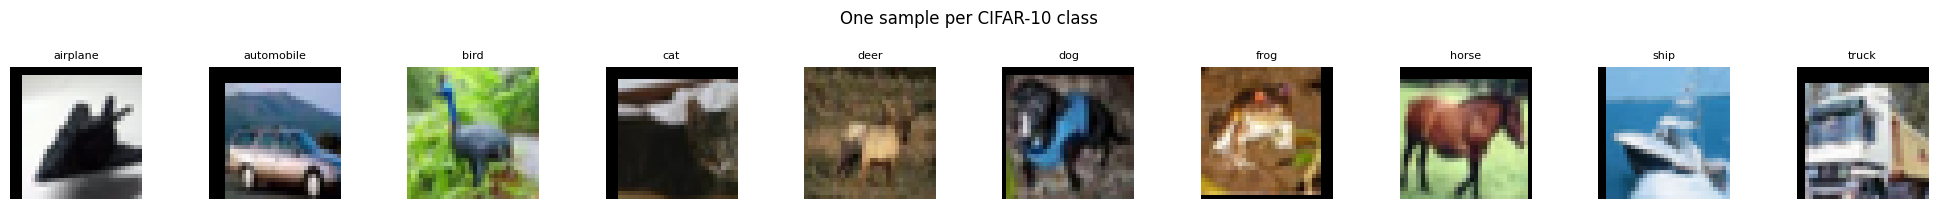

In [7]:
inv_mean = torch.tensor(CIFAR10_MEAN).view(3, 1, 1)
inv_std  = torch.tensor(CIFAR10_STD).view(3, 1, 1)

fig, axes = plt.subplots(1, 10, figsize=(20, 2))
shown = set()
idx = 0
while len(shown) < 10:
    image, label = train_dataset[idx]
    idx += 1
    if label in shown:
        continue
    shown.add(label)
    display_img = (image * inv_std + inv_mean).clamp(0, 1).permute(1, 2, 0).numpy()
    ax = axes[label]
    ax.imshow(display_img)
    ax.set_title(CLASS_NAMES[label], fontsize=8)
    ax.axis('off')

plt.suptitle("One sample per CIFAR-10 class", y=1.02)
plt.tight_layout()
plt.show()

# Training and Evaluating a CNN Classifier

In [8]:
class CIFAR10Model(nn.Module):
    def __init__(self, num_classes=10):
        """
        Input: (3, 32, 32)  -- RGB images
        """
        super(CIFAR10Model, self).__init__()

        # Convolutional feature extractor
        # Block 1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)   # (32, 32, 32)
        self.bn1   = nn.BatchNorm2d(32)

        # Block 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # (64, 32, 32)
        self.bn2   = nn.BatchNorm2d(64)

        # Block 3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1) # (128, 32, 32)
        self.bn3   = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.25)

        # Spatial sizes after pooling:
        #   32 -> 16 (after pool1)
        #   16 ->  8 (after pool2)
        #    8 ->  4 (after pool3)
        # Final feature map: (128, 4, 4)  => 2048 elements
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):

        x = self.pool(F.relu(self.bn1(self.conv1(x))))   # (32, 16, 16)
        x = self.pool(F.relu(self.bn2(self.conv2(x))))   # (64, 8, 8)
        x = self.pool(F.relu(self.bn3(self.conv3(x))))   # (128, 4, 4)

        x = self.dropout(x)
        x = x.view(x.size(0), -1)                        # flatten -> (batch, 2048)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [9]:
summary(CIFAR10Model().to(DEVICE), (3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
       BatchNorm2d-2           [-1, 32, 32, 32]              64
         MaxPool2d-3           [-1, 32, 16, 16]               0
            Conv2d-4           [-1, 64, 16, 16]          18,496
       BatchNorm2d-5           [-1, 64, 16, 16]             128
         MaxPool2d-6             [-1, 64, 8, 8]               0
            Conv2d-7            [-1, 128, 8, 8]          73,856
       BatchNorm2d-8            [-1, 128, 8, 8]             256
         MaxPool2d-9            [-1, 128, 4, 4]               0
          Dropout-10            [-1, 128, 4, 4]               0
           Linear-11                  [-1, 256]         524,544
          Dropout-12                  [-1, 256]               0
           Linear-13                   [-1, 10]           2,570
Total params: 620,810
Trainable params:

In [10]:
cifar_model = CIFAR10Model().to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cifar_model.parameters(), lr=0.001, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

NUM_EPOCHS = 50

In [11]:
# Training and Evaluation Loop
epoch_train_losses = []
epoch_test_losses  = []
epoch_train_accuracies = []
epoch_test_accuracies  = []

for epoch in range(NUM_EPOCHS):
    # Train
    cifar_model.train()
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    for images, labels in pbar:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = cifar_model(images)
        loss = criterion(outputs, labels)
        pbar.set_postfix({"loss": f"{loss.item():.3f}"})
        loss.backward()
        optimizer.step()

    scheduler.step()

    # Evaluate
    cifar_model.eval()
    train_loss = test_loss = 0.0
    correct_train = correct_test = 0

    with torch.no_grad():
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = cifar_model(images)
            train_loss    += criterion(outputs, labels).item() * images.size(0)
            _, predicted   = torch.max(outputs.data, 1)
            correct_train += (predicted == labels).sum().item()

        for images, labels in test_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = cifar_model(images)
            test_loss    += criterion(outputs, labels).item() * images.size(0)
            _, predicted  = torch.max(outputs.data, 1)
            correct_test += (predicted == labels).sum().item()

    epoch_train_losses.append(train_loss / len(train_dataset))
    epoch_test_losses.append(test_loss  / len(test_dataset))
    epoch_train_accuracies.append(100. * correct_train / len(train_dataset))
    epoch_test_accuracies.append(100.  * correct_test  / len(test_dataset))

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - "
          f"Train Loss: {epoch_train_losses[-1]:.4f}, "
          f"Test Loss: {epoch_test_losses[-1]:.4f}, "
          f"Train Acc: {epoch_train_accuracies[-1]:.2f}%, "
          f"Test Acc: {epoch_test_accuracies[-1]:.2f}%\n")

Epoch 1/50: 100%|██████████| 391/391 [00:04<00:00, 81.95it/s, loss=1.272]


Epoch 1/50 - Train Loss: 1.2548, Test Loss: 1.1693, Train Acc: 54.61%, Test Acc: 57.55%



Epoch 2/50: 100%|██████████| 391/391 [00:04<00:00, 91.47it/s, loss=1.082]


Epoch 2/50 - Train Loss: 1.0218, Test Loss: 0.9516, Train Acc: 64.04%, Test Acc: 66.33%



Epoch 3/50: 100%|██████████| 391/391 [00:04<00:00, 89.38it/s, loss=1.220]


...

Epoch 48/50 - Train Loss: 0.3456, Test Loss: 0.4339, Train Acc: 88.18%, Test Acc: 85.22%



Epoch 49/50: 100%|██████████| 391/391 [00:04<00:00, 90.87it/s, loss=0.510]


Epoch 49/50 - Train Loss: 0.3477, Test Loss: 0.4338, Train Acc: 87.88%, Test Acc: 85.15%



Epoch 50/50: 100%|██████████| 391/391 [00:04<00:00, 88.97it/s, loss=0.379]


Epoch 50/50 - Train Loss: 0.3468, Test Loss: 0.4334, Train Acc: 88.03%, Test Acc: 85.21%



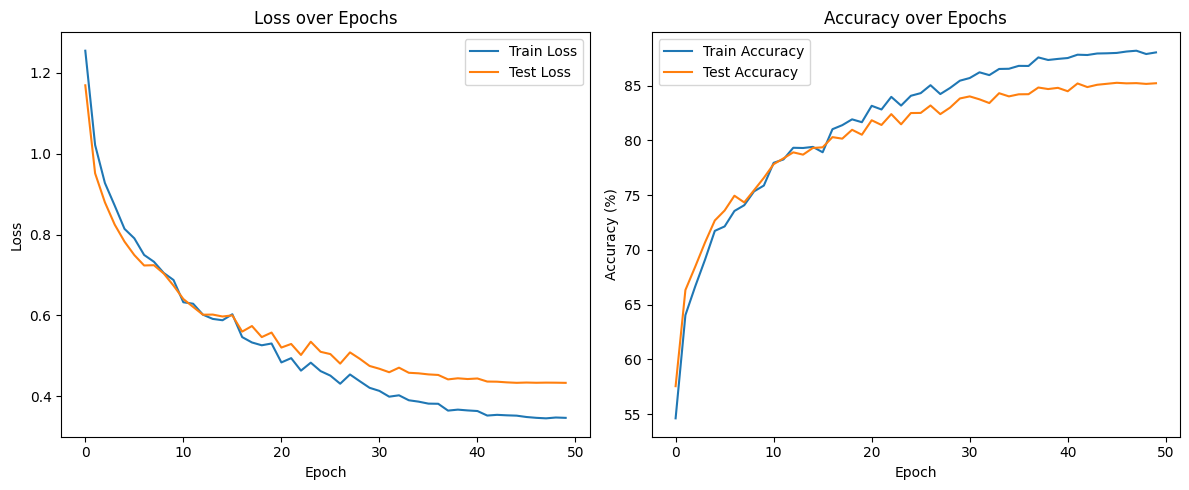

In [12]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epoch_train_losses, label='Train Loss')
plt.plot(epoch_test_losses,  label='Test Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epoch_train_accuracies, label='Train Accuracy')
plt.plot(epoch_test_accuracies,  label='Test Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

# MIFace Model Inversion Attack

**MIFace** is a white-box model inversion technique designed to reconstruct representative inputs for a target class from a trained classifier.

Let the trained classifier be represented as a function $f_{\boldsymbol{\theta}}(\mathbf{x})$, where $\mathbf{x} \in \mathbb{R}^d$ denotes the input vector and $\boldsymbol{\theta}$ denotes the model parameters. The model outputs a probability vector $\mathbf{p} = f_{\boldsymbol{\theta}}(\mathbf{x})$ over $K$ classes.

For a target class $y_t$, the objective is to reconstruct an input $\mathbf{x}^*$ that maximizes the probability assigned to that class, i.e.,

$$
x^* = \arg\max_{\mathbf{x}} \; f_{\boldsymbol{\theta}}(\mathbf{x})_{y_t}
$$

To prevent unrealistic reconstructions, a regularization term is included. The complete objective becomes

$$
x^* = \arg\max_{\mathbf{x}} \left[ \log f_{\boldsymbol{\theta}}(\mathbf{x})_{y_t} - \lambda ||{\mathbf{x}}||_2^2 \right]
$$

where $\lambda$ controls the strength of the prior on the reconstructed input.

The optimization is solved using gradient ascent starting from a random initialization $\mathbf{x}_0$, the update rule at iteration $t$ is

$$
\mathbf{x}_{t+1} = \mathbf{x}_t + \eta \nabla_{\mathbf{x}} \left(\log f_{\boldsymbol{\theta}}(\mathbf{x}_t)_{y_t} - \lambda ||\mathbf{x}_t||_2^2 \right)
$$

where $\eta$ is the step size. The gradient $\nabla_{\mathbf{x}} \log f_{\boldsymbol{\theta}}(\mathbf{x})_{y_t}$ is computed by backpropagating through the network with respect to the input tensor $\mathbf{x}$.

In practice, the reconstructed input often resembles an **average prototype** of the training samples belonging to that class, revealing sensitive characteristics encoded in the model.

In [38]:
classifier = PyTorchClassifier(
    model=cifar_model,
    loss=nn.CrossEntropyLoss,
    optimizer=torch.optim.Adam,
    nb_classes=NUM_CLASSES,       # 10
    input_shape=(3, 32, 32),      # RGB 32x32
)

attack = MIFace(
    classifier=classifier,
    max_iter=10000,
    threshold=0.95,
    learning_rate=0.001,
    window_length=100
)

In [39]:
y = np.arange(NUM_CLASSES)  # [0, 1, ..., 9]

x_init_white  = np.zeros((NUM_CLASSES, 3, 32, 32), dtype=np.float32)
x_init_grey   = np.ones( (NUM_CLASSES, 3, 32, 32), dtype=np.float32) * 0.5
x_init_black  = np.ones( (NUM_CLASSES, 3, 32, 32), dtype=np.float32)
x_init_random = np.random.uniform(0, 1, (NUM_CLASSES, 3, 32, 32)).astype(np.float32)

x_init_dist   = np.random.normal(
    mean_scalar, std_scalar, (NUM_CLASSES, 3, 32, 32)
).astype(np.float32)

In [40]:
print(x_init_white.shape, x_init_grey.shape, x_init_black.shape,
      x_init_random.shape, x_init_dist.shape)

(10, 3, 32, 32) (10, 3, 32, 32) (10, 3, 32, 32) (10, 3, 32, 32) (10, 3, 32, 32)


## Evaluate Initializations

In [41]:
def evaluate_inversion(attack_object, classifier, x, y, title=""):
    """
    Run MIFace inversion from initial images `x` for target labels `y` and
    display the reconstructed images.

    For CIFAR-10 the images are RGB (3, 32, 32), so we permute axes for display.
    """
    class_gradient = classifier.class_gradient(x, y)
    print(f"Max Gradient Norm: {class_gradient.max():.4f}")
    print(f"Min Gradient Norm: {class_gradient.min():.4f}")

    x_infer = attack_object.infer(x, y)

    # x_infer is a numpy array of shape (10, 3, 32, 32)
    # Normalise each image to [0,1] for display
    fig, axes = plt.subplots(2, 5, figsize=(14, 6))
    if title:
        fig.suptitle(title, fontsize=14, fontweight='bold')

    for i in range(NUM_CLASSES):
        ax = axes[i // 5][i % 5]
        img = x_infer[i]          # shape (3, 32, 32)
        # Shift to [0, 1] for visualisation
        img = img - img.min()
        if img.max() > 0:
            img = img / img.max()
        img = np.transpose(img, (1, 2, 0))  # (H, W, C) for imshow
        ax.imshow(img.clip(0, 1))
        ax.set_title(f"Class {i}\n{CLASS_NAMES[i]}", fontsize=8)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

### White Initialization

Max Gradient Norm: 0.2797
Min Gradient Norm: -0.4234


Model inversion:   0%|          | 0/10 [00:00<?, ?it/s]

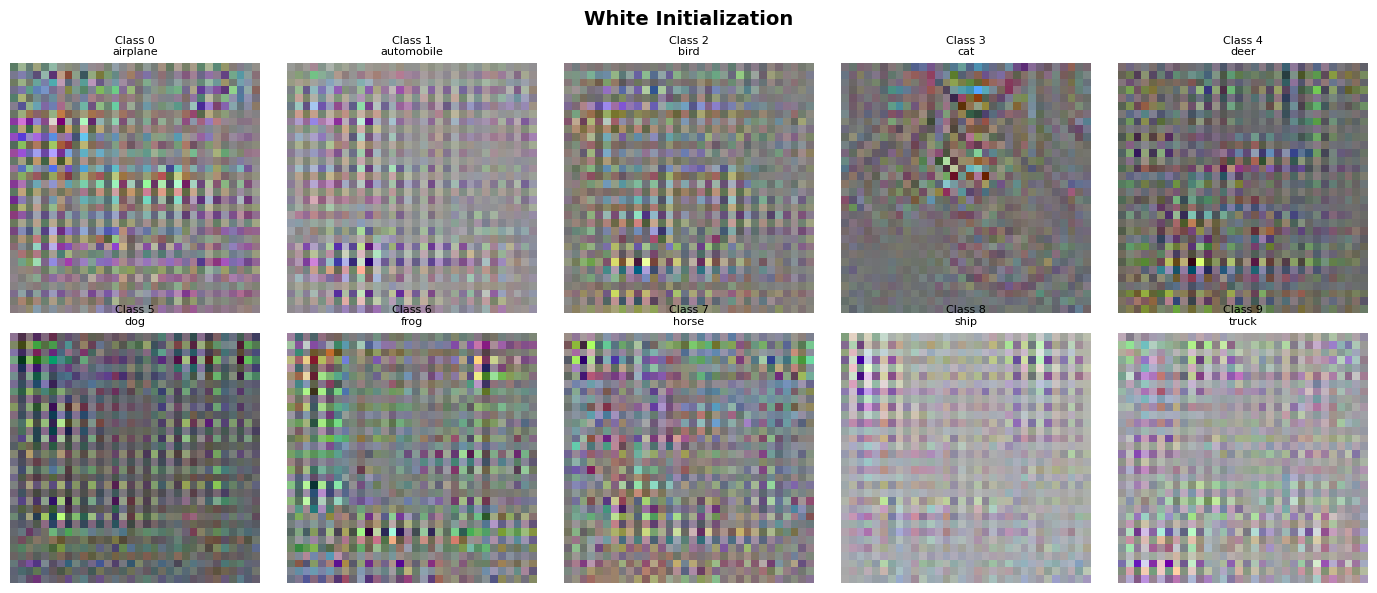

In [42]:
evaluate_inversion(attack, classifier, x_init_white, y, title="White Initialization")

### Grey Initialization

Max Gradient Norm: 0.3839
Min Gradient Norm: -0.6074


Model inversion:   0%|          | 0/10 [00:00<?, ?it/s]

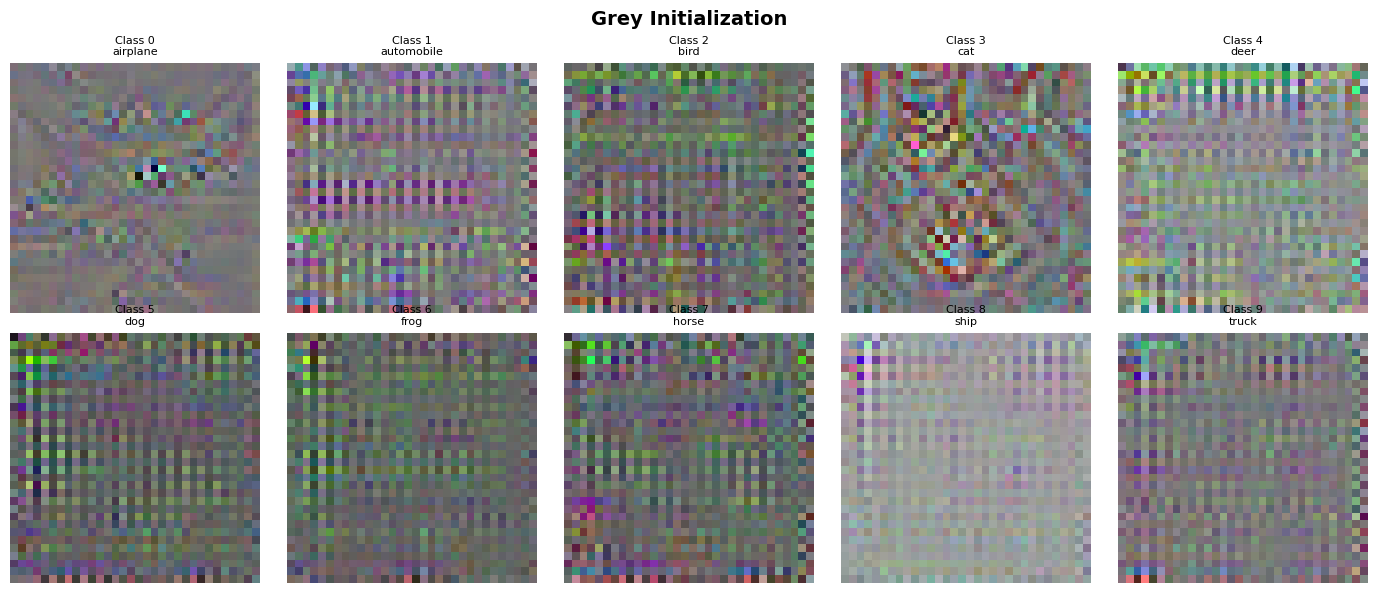

In [43]:
evaluate_inversion(attack, classifier, x_init_grey, y, title="Grey Initialization")

### Black Initialization

Max Gradient Norm: 0.2784
Min Gradient Norm: -0.2802


Model inversion:   0%|          | 0/10 [00:00<?, ?it/s]

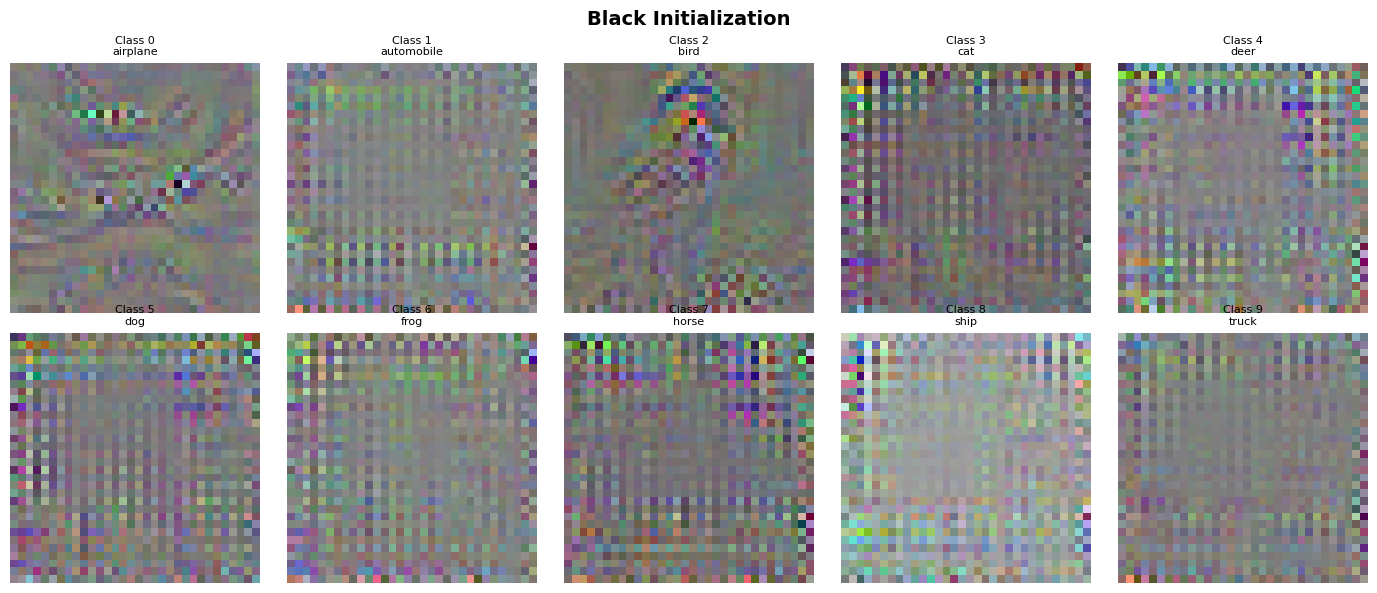

In [44]:
evaluate_inversion(attack, classifier, x_init_black, y, title="Black Initialization")

### Random Initialization

Max Gradient Norm: 0.6413
Min Gradient Norm: -0.6010


Model inversion:   0%|          | 0/10 [00:00<?, ?it/s]

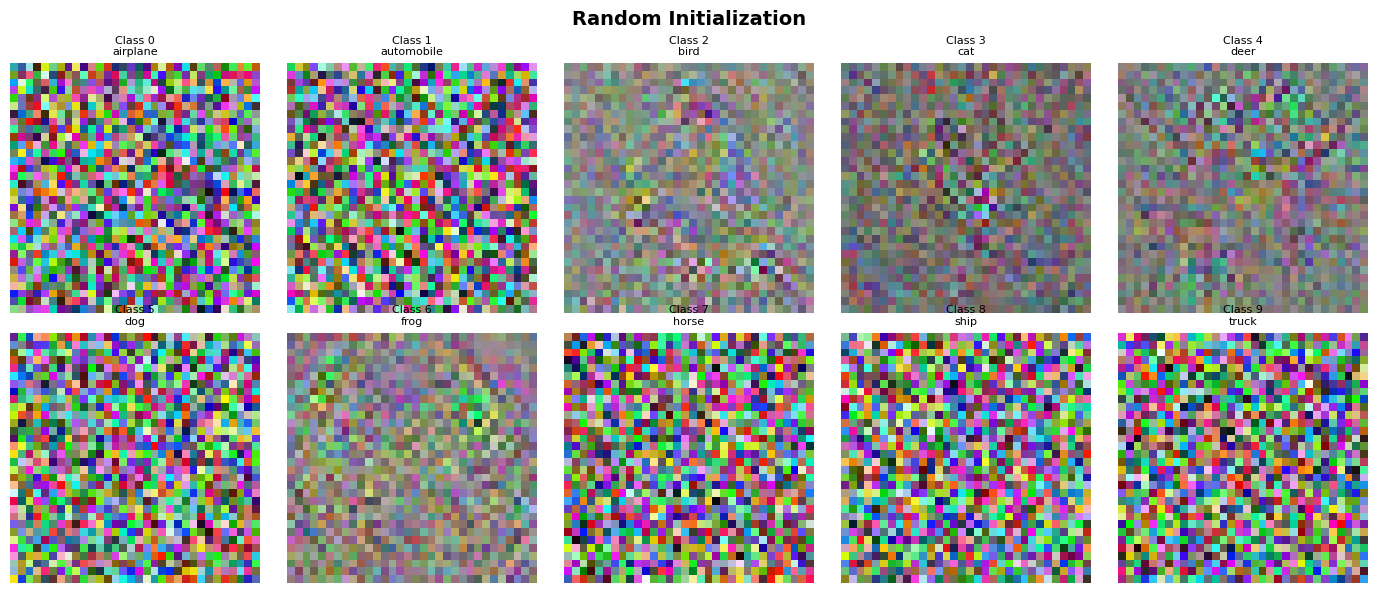

In [45]:
evaluate_inversion(attack, classifier, x_init_random, y, title="Random Initialization")

### Sampled Initialization

Max Gradient Norm: 0.7035
Min Gradient Norm: -0.7384


Model inversion:   0%|          | 0/10 [00:00<?, ?it/s]

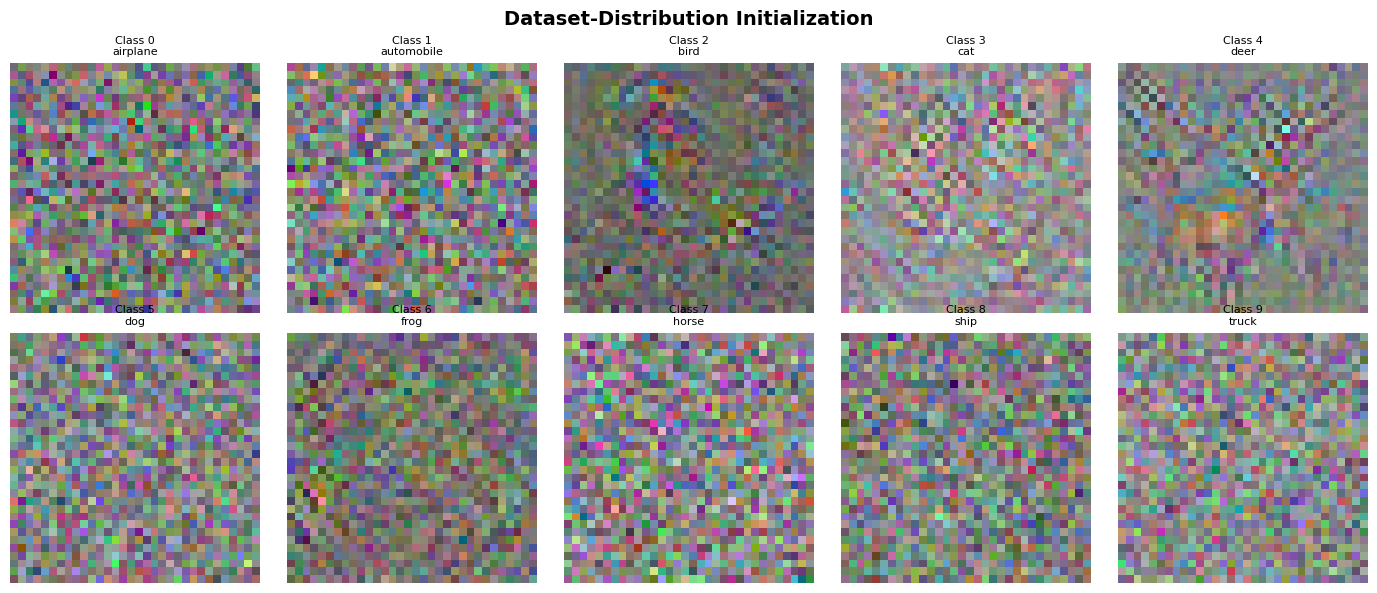

In [46]:
evaluate_inversion(attack, classifier, x_init_dist, y, title="Dataset-Distribution Initialization")